Data-Driven Salary Analysis and Prediction Across Job Markets


In today’s evolving job market, understanding the factors that influence employee salaries is critical for job seekers, employers, and policymakers. However, salary determination is complex and influenced by multiple variables such as job role, level of experience, educational background, skill sets, and industry sector. The lack of clear, data-driven insights makes it difficult for individuals to benchmark their earnings and for organizations to ensure competitive and fair compensation.

This project aims to analyze a large-scale dataset of 250,000 job records obtained from Kaggle to uncover key factors that drive salary variations across different professions and industries. The study will explore relationships between salary and attributes such as experience level, education, job role, and required skills.

Furthermore, the project seeks to develop a predictive model capable of estimating salaries based on these features, providing a practical tool for salary benchmarking and decision-making.

The insights derived from this analysis will help:

1. Job seekers understand how to position themselves for higher earnings
2. Employers design competitive compensation strategies
3. Analysts and researchers identify trends within the labor market


In [7]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning (for later stages)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [12]:
# Load dataset
df = pd.read_csv(r"C:/Users/kirii/Downloads/job_salary_prediction_dataset.csv")

# Preview first 5 rows
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [14]:
df.shape

(250000, 10)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [17]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [18]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [23]:
df.dtypes

job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object

<Axes: xlabel='salary'>

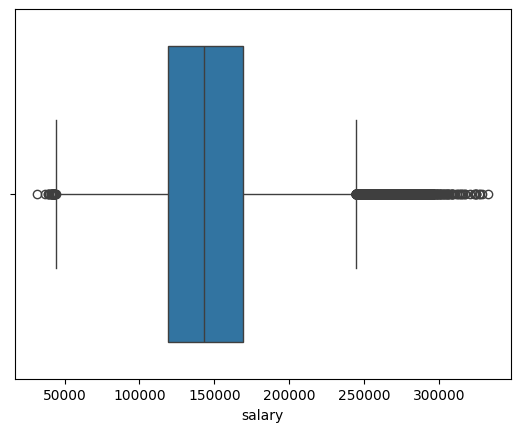

In [24]:
import seaborn as sns
sns.boxplot(x=df['salary'])

In [28]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [29]:
# Summary statistics
df.describe()

# For categorical data
df.describe(include='object')

,job_title,education_level,industry,company_size,location,remote_work
count,250000,250000,250000,250000,250000,250000
unique,12,5,10,5,10,3
top,Backend Developer,Master,Finance,Large,Australia,No
freq,21125,50352,25393,50254,25258,83621


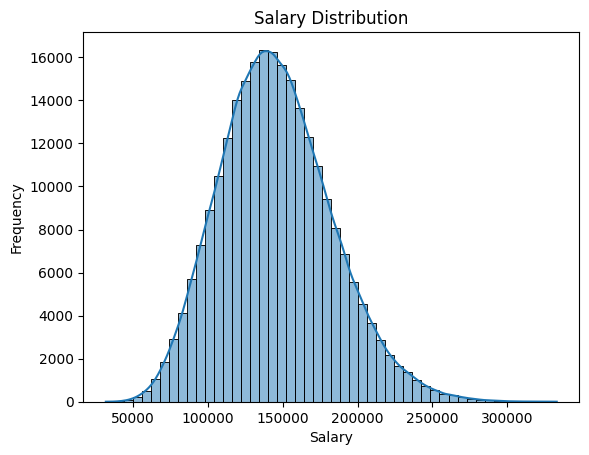

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['salary'], bins=50, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

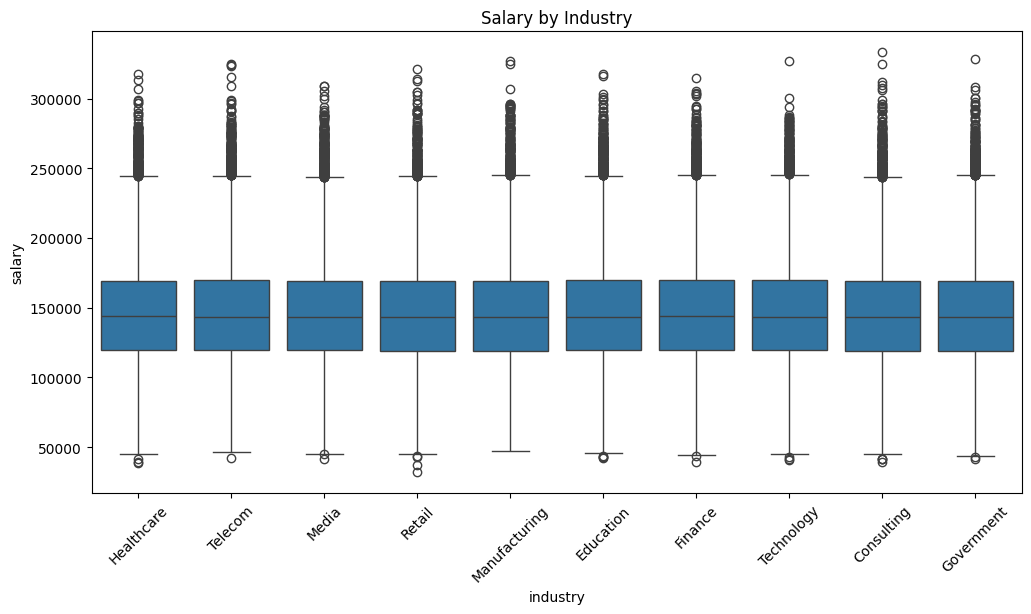

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(x='industry', y='salary', data=df)
plt.xticks(rotation=45)
plt.title('Salary by Industry')
plt.show()

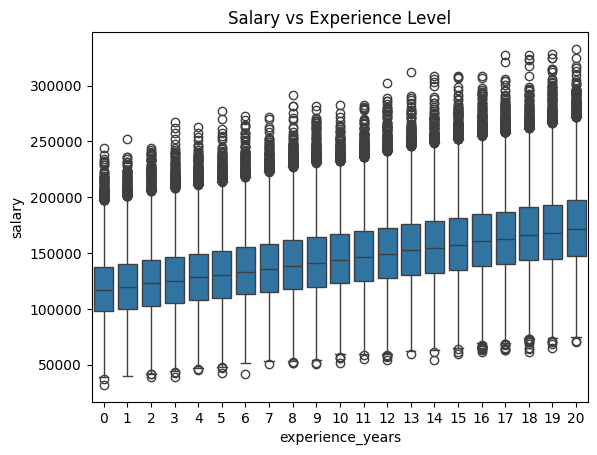

In [33]:
sns.boxplot(x='experience_years', y='salary', data=df)
plt.title('Salary vs Experience Level')
plt.show()

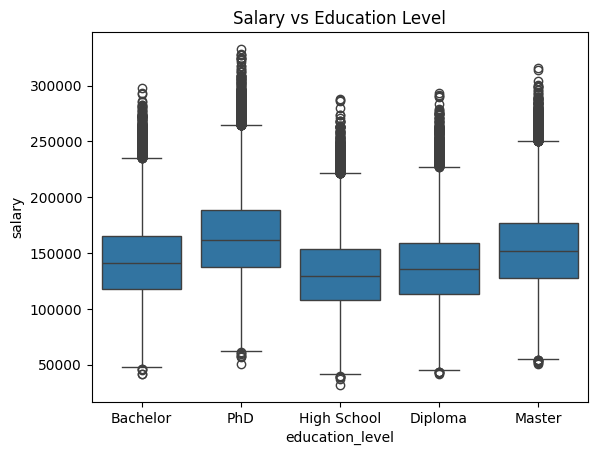

In [34]:
sns.boxplot(x='education_level', y='salary', data=df)
plt.title('Salary vs Education Level')
plt.show()

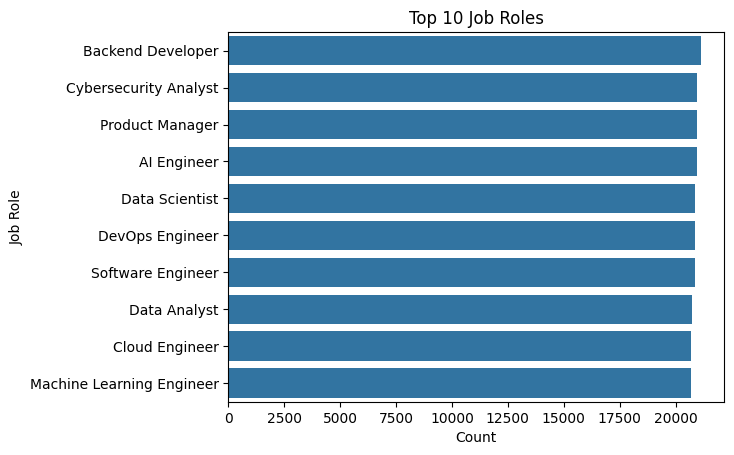

In [37]:
top_roles = df['job_title'].value_counts().head(10)

sns.barplot(x=top_roles.values, y=top_roles.index)
plt.title('Top 10 Job Roles')
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.show()

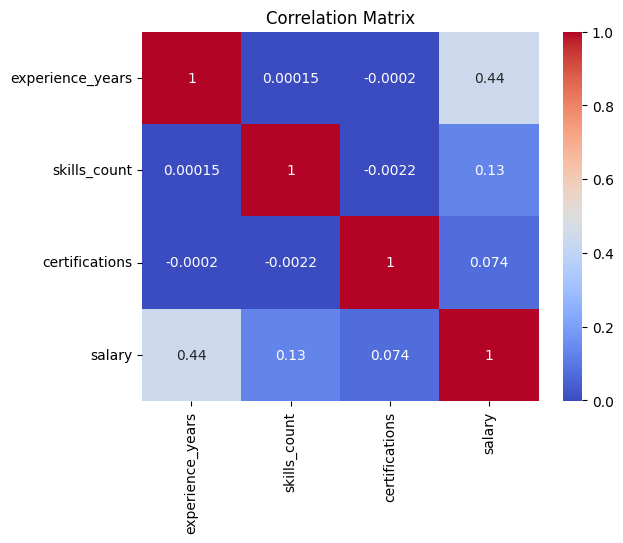

In [38]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [39]:
df['log_salary'] = np.log1p(df['salary'])

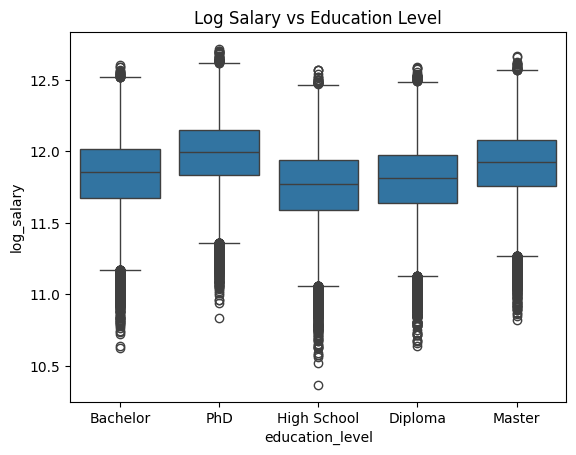

In [40]:
sns.boxplot(x='education_level', y='log_salary', data=df)
plt.title('Log Salary vs Education Level')
plt.show()

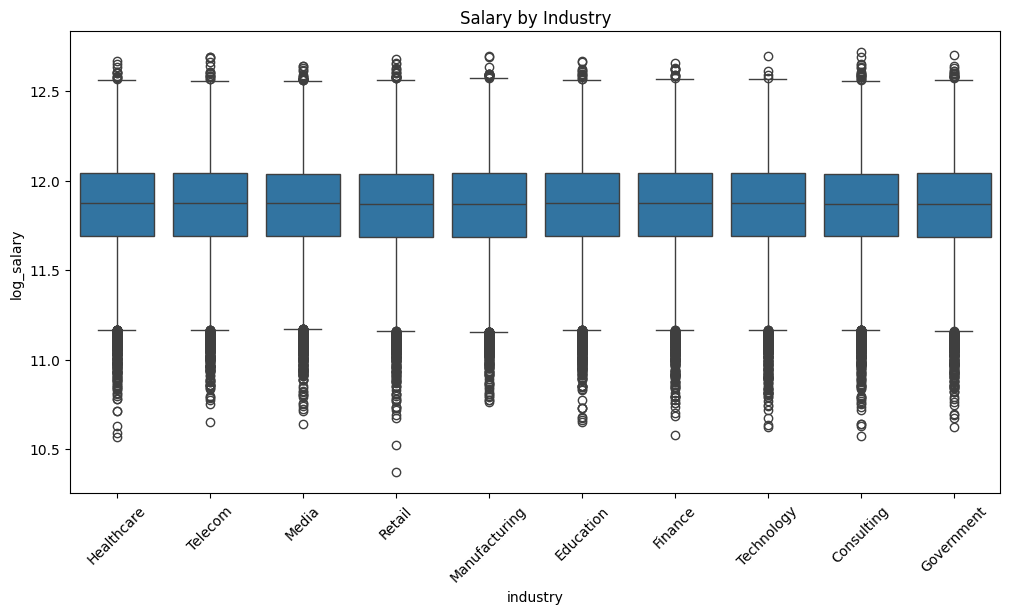

In [41]:
plt.figure(figsize=(12,6))
sns.boxplot(x='industry', y='log_salary', data=df)
plt.xticks(rotation=45)
plt.title('Salary by Industry')
plt.show()

The salary distribution exhibits significant skewness due to the presence of high-income earners. Rather than removing these values, they were retained as they represent valid real-world observations.

To improve interpretability, a log transformation was applied to the salary variable, enabling clearer visualization of underlying patterns.

Analysis reveals that:

1. Salary increases consistently with years of experience, indicating a strong positive relationship
2. Higher education levels (particularly PhD and Master’s) are associated with higher median salaries
3. However, substantial overlap across education levels suggests that experience and other factors may play a more significant role in determining salary
4. Experience years are significant when it comes the salary one is paid.

SALARY PREDICTION MODEL

In [43]:
# Features and target
X = df.drop(['salary', 'log_salary'], axis=1, errors='ignore')
y = df['salary']

In [44]:
# Convert categorical variables into numbers
X = pd.get_dummies(X, drop_first=True)

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
y_pred = model.predict(X_test_scaled)

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5436.096936751814
RMSE: 7125.522904124911
R2 Score: 0.9634690228446959


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.9608581821826041


In [51]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

experience_years              0.200342
location_India                0.181792
location_USA                  0.075682
company_size_Startup          0.061108
education_level_PhD           0.060730
company_size_Small            0.050843
job_title_Data Analyst        0.044606
company_size_Medium           0.043669
job_title_Business Analyst    0.042465
location_Canada               0.034414
dtype: float64